# Resumen de Apuntes - PyTorch Classification (Multiclase)

**Referencia:** 02_pytorch_classification.ipynb (puntos 8-9)

En este notebook cubrimos **clasificación multiclase** (4+ clases) con PyTorch y métricas de evaluación avanzadas.

## Contenidos
- **Punto 8:** Construcción de datos y modelo multiclase
- **Punto 9:** Métricas de evaluación (Precision, Recall, F1, Confusion Matrix)

## Punto 8 - Multiclase: Construcción Completa

### 8.1 Crear Datos Multiclase

**Objetivo:** Generar 4 clases (clusters) usando `make_blobs()`.

**Diferencias vs Binary:**
- y_blob: LongTensor (índice de clase, no float)
- 4 salidas en el modelo (una por clase)

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Hiperparámetros
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Crear datos
X_blob, y_blob = make_blobs(n_samples=1000,
                             n_features=NUM_FEATURES,
                             centers=NUM_CLASSES,
                             cluster_std=1.5,
                             random_state=RANDOM_SEED)

# 2. Convertir a tensores
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)  # ← LongTensor, no float

# 3. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_blob, y_blob,
                                                      test_size=0.2,
                                                      random_state=RANDOM_SEED)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Clases: {torch.unique(y_blob)}")
print(f"y_train dtype: {y_train.dtype}  (note: LongTensor)")

X_train shape: torch.Size([800, 2])
y_train shape: torch.Size([800])
Clases: tensor([0, 1, 2, 3])
y_train dtype: torch.int64  (note: LongTensor)


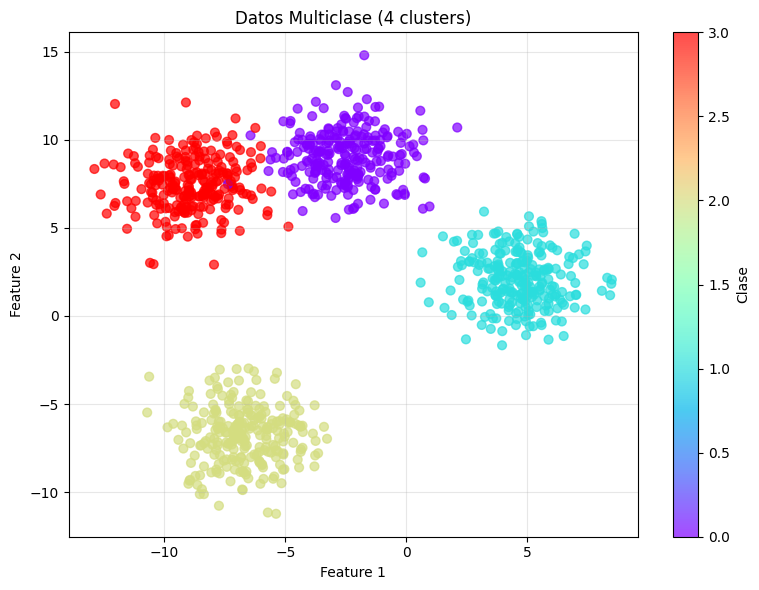


Observación: 4 clusters bien separados (frontera casi lineal es posible)


In [2]:
# 4. Visualizar
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap='rainbow', s=40, alpha=0.7)
plt.title(f'Datos Multiclase ({NUM_CLASSES} clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(scatter, label='Clase')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

print(f"\nObservación: 4 clusters bien separados (frontera casi lineal es posible)")

### 8.2 Modelo Multiclase

**Arquitectura:**
- Entrada: 2 features
- Salida: 4 logits (uno por clase)

**Clave:** Sin activación en salida (entrega logits crudos)

In [3]:
# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Modelo
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),  # ← No-linealidad
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)  # ← 4 logits
        )
    
    def forward(self, x):
        return self.linear_layer_stack(x)

model = BlobModel(input_features=NUM_FEATURES,
                  output_features=NUM_CLASSES,
                  hidden_units=8).to(device)

print(f"\nModelo:\n{model}")

Device: cuda

Modelo:
BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)


### 8.3 Loss y Optimizer para Multiclase

**Loss:** `CrossEntropyLoss` (no BCEWithLogitsLoss)
- Recibe logits y etiquetas de clase directamente
- Incluye softmax + NLL internamente

**Optimizer:** SGD (igual que antes)

In [4]:
# Loss y Optimizer
loss_fn = nn.CrossEntropyLoss()  # ← Para multiclase
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

print(f"Loss: {loss_fn}")
print(f"Optimizer: {optimizer}")

Loss: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### 8.4 De Logits a Clase: Softmax + Argmax

**Proceso:**
1. Modelo → logits (4 valores por muestra)
2. Softmax → probabilidades (suma a 1)
3. Argmax → índice de clase con mayor probabilidad

In [5]:
# Test forward pass
X_test_sample = X_test[:3].to(device)
model.eval()
with torch.inference_mode():
    y_logits = model(X_test_sample)
    print(f"Logits (crudos):\n{y_logits}\n")
    
    # Convertir a probabilidades
    y_probs = torch.softmax(y_logits, dim=1)
    print(f"Probabilidades (softmax):\n{y_probs}\n")
    print(f"Suma por fila (debe ser 1): {y_probs.sum(dim=1)}\n")
    
    # Clase predicha
    y_pred = y_probs.argmax(dim=1)
    print(f"Clase predicha (argmax): {y_pred}")
    print(f"\nEjemplo: Muestra 0 tiene mayor probabilidad en clase {y_pred[0]}")

Logits (crudos):
tensor([[ 1.0676,  0.1433, -0.5570, -0.2987],
        [ 0.8294,  0.7840,  1.2166, -0.3635],
        [ 0.1478,  0.1256,  0.2165, -0.3165]], device='cuda:0')

Probabilidades (softmax):
tensor([[0.5409, 0.2146, 0.1065, 0.1380],
        [0.2680, 0.2561, 0.3947, 0.0813],
        [0.2719, 0.2659, 0.2912, 0.1709]], device='cuda:0')

Suma por fila (debe ser 1): tensor([1.0000, 1.0000, 1.0000], device='cuda:0')

Clase predicha (argmax): tensor([0, 2, 2], device='cuda:0')

Ejemplo: Muestra 0 tiene mayor probabilidad en clase 0


### 8.5 Training Loop para Multiclase

**Similitud con Binary:**
- Pasos iguales (forward, loss, backward, step)

**Diferencia clave:**
- Uso de softmax + argmax en lugar de sigmoid + round
- CrossEntropyLoss en lugar de BCEWithLogitsLoss

In [7]:
# Mover datos a device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Entrenar
torch.manual_seed(42)
epochs = 100

train_acc_history = []
test_acc_history = []

print("⏳ Iniciando entrenamiento (100 epochs)...\n")

for epoch in range(epochs):
    # === TRAINING ===
    model.train()
    
    # Forward
    y_logits = model(X_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    
    # Loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)
    train_acc_history.append(acc)
    
    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # === TESTING ===
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)
    
    test_acc_history.append(test_acc)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Acc: {acc:6.2f}% | Test Acc: {test_acc:6.2f}%")

print(f"\n✅ Entrenamiento completado.")
print(f"Accuracy final: Train {train_acc_history[-1]:.2f}%, Test {test_acc_history[-1]:.2f}%")

⏳ Iniciando entrenamiento (100 epochs)...

Epoch   0 | Train Acc:  32.12% | Test Acc:  48.00%
Epoch  10 | Train Acc:  99.25% | Test Acc:  99.50%
Epoch  20 | Train Acc:  99.25% | Test Acc:  99.50%
Epoch  30 | Train Acc:  99.25% | Test Acc:  99.50%
Epoch  40 | Train Acc:  99.25% | Test Acc:  99.50%
Epoch  50 | Train Acc:  99.25% | Test Acc:  99.50%
Epoch  60 | Train Acc:  99.25% | Test Acc:  99.50%
Epoch  70 | Train Acc:  99.25% | Test Acc:  99.50%
Epoch  80 | Train Acc:  99.25% | Test Acc:  99.50%
Epoch  90 | Train Acc:  99.25% | Test Acc:  99.50%

✅ Entrenamiento completado.
Accuracy final: Train 99.25%, Test 99.50%


## Punto 9 - Métricas de Evaluación Avanzadas

### 9.1 ¿Por qué más métricas?

**Problema:** Accuracy puede engañar en clases desbalanceadas.

**Ejemplo:** Dataset con 99% positivos
- Modelo que siempre predice "positivo" → 99% accuracy
- Pero es inútil para detectar negativos

**Solución:** Usar Precision, Recall, F1, Confusion Matrix.

### 9.2 Tabla de Métricas

| Métrica | Qué mide | Cuándo importa | Rango |
|---------|----------|---|---|
| **Accuracy** | Aciertos totales / total | Clases balanceadas | 0-100% |
| **Precision** | VP / (VP + FP) | Falsos positivos son caros | 0-100% |
| **Recall** | VP / (VP + FN) | Falsos negativos son caros | 0-100% |
| **F1-score** | Media armónica P y R | Balance entre ambos | 0-1 |
| **Confusion Matrix** | Tabla errores vs aciertos | Entender dónde falla | - |

Donde:
- **VP** = Verdaderos Positivos
- **FP** = Falsos Positivos
- **FN** = Falsos Negativos
- **VN** = Verdaderos Negativos

### 9.3 Calcular Métricas con Scikit-Learn

**Mejor que replicarlas:** Usar librerías probadas.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predictions finales
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)
    y_pred_final = torch.softmax(test_logits, dim=1).argmax(dim=1).cpu().numpy()

y_test_np = y_test.cpu().numpy()

# Calcular métricas
acc = accuracy_score(y_test_np, y_pred_final)
precision = precision_score(y_test_np, y_pred_final, average='weighted')
recall = recall_score(y_test_np, y_pred_final, average='weighted')
f1 = f1_score(y_test_np, y_pred_final, average='weighted')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}  (weighted)")
print(f"Recall:    {recall:.4f}  (weighted)")
print(f"F1-score:  {f1:.4f}  (weighted)")

Accuracy:  0.9950
Precision: 0.9951  (weighted)
Recall:    0.9950  (weighted)
F1-score:  0.9950  (weighted)


Confusion Matrix:
[[49  0  0  0]
 [ 0 41  0  0]
 [ 0  0 53  0]
 [ 1  0  0 56]]



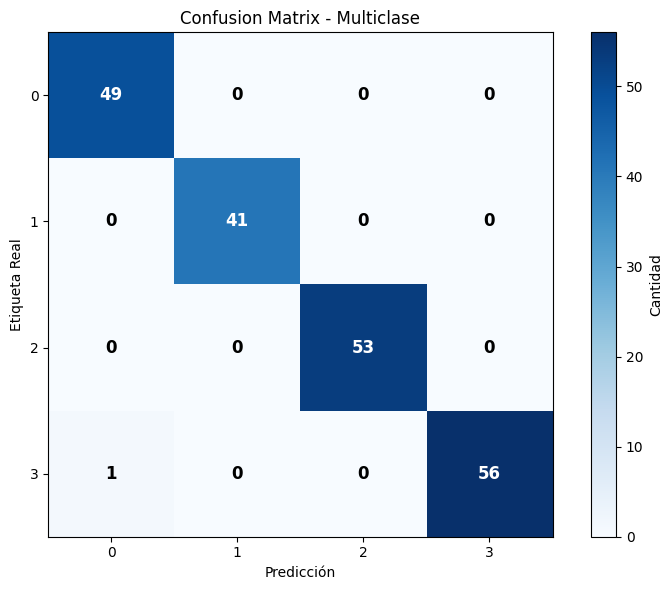


Interpretación:
- Diagonal: aciertos por clase
- Fuera diagonal: confusiones (error)


In [9]:
# Confusion Matrix
import numpy as np

cm = confusion_matrix(y_test_np, y_pred_final)
print(f"Confusion Matrix:\n{cm}\n")

# Visualizar
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix - Multiclase')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.colorbar(label='Cantidad')

# Anotar valores
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=12, fontweight='bold')

plt.xticks(range(NUM_CLASSES))
plt.yticks(range(NUM_CLASSES))
plt.tight_layout()
plt.show()
plt.close()

print(f"\nInterpretación:")
print(f"- Diagonal: aciertos por clase")
print(f"- Fuera diagonal: confusiones (error)")

In [10]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test_np, y_pred_final,
                           target_names=[f'Clase {i}' for i in range(NUM_CLASSES)]))

print(f"\nInterpretación:")
print(f"- 'precision': de lo que predice clase X, cuánto es correcto")
print(f"- 'recall': de todos los ejemplos clase X, cuántos encontró")
print(f"- 'f1-score': balance entre precision y recall")
print(f"- 'support': cantidad de muestras por clase")

Classification Report:
              precision    recall  f1-score   support

     Clase 0       0.98      1.00      0.99        49
     Clase 1       1.00      1.00      1.00        41
     Clase 2       1.00      1.00      1.00        53
     Clase 3       1.00      0.98      0.99        57

    accuracy                           0.99       200
   macro avg       0.99      1.00      1.00       200
weighted avg       1.00      0.99      1.00       200


Interpretación:
- 'precision': de lo que predice clase X, cuánto es correcto
- 'recall': de todos los ejemplos clase X, cuántos encontró
- 'f1-score': balance entre precision y recall
- 'support': cantidad de muestras por clase


### 9.4 Casos Prácticos

**Caso 1: Detector de Spam**
- Importa evitar falsos positivos (bloquear correo legítimo)
- Métrica clave: **Precision**

**Caso 2: Diagnóstico Médico**
- Importa no perder casos enfermos (falsos negativos)
- Métrica clave: **Recall**

**Caso 3: Balancear ambos**
- Métrica clave: **F1-score**

## Comparativa Final: Binary vs Multiclase

| Aspecto | Binary | Multiclase |
|--------|--------|------------|
| **Salida modelo** | 1 logit | N logits |
| **Tipo y** | float (0 o 1) | LongTensor (0,1,2,...,N-1) |
| **Loss** | BCEWithLogitsLoss | CrossEntropyLoss |
| **Activación → probs** | sigmoid | softmax |
| **Probs → clase** | round (>0.5) | argmax |
| **Métrica simple** | accuracy | accuracy |
| **Métricas avanzadas** | precision (binary), recall | precision (macro/weighted), recall, F1 |

**Plantilla de decisión:**
- 2 clases → Binary (más simple)
- 3+ clases → Multiclase

## Checklist Final

✅ Datos preparados y visualizados
✅ Modelo con arquitectura adecuada (no-linealidad)
✅ Loss y optimizer correctos
✅ Training loop con evaluación
✅ Predicciones convertidas a clases
✅ Múltiples métricas calculadas
✅ Confusion matrix visualizada
✅ Decisión sobre métrica principal según caso de uso

**Ahora estás listo para:**
- Construir modelos de clasificación (binary y multiclase)
- Entrenarlos correctamente
- Evaluarlos con las métricas apropiadas